## Pipeline 3 — Molecular Dynamics and Comparative Energetic Analysis

This notebook continues directly from:

```text
07a_EGFR_Dimer_OpenMM_MD_Setup.ipynb


## 1. Requirements

Use the same environment as `07a`:

```text
Python (PEARL MD)
```

MDAnalysis is additionally required.

Recommended installation from the terminal:

```bash
conda activate pearl-md
conda install -c conda-forge mdanalysis -y
```

Then restart the Jupyter kernel.

The notebook expects the outputs from `07a` under:

```text
outputs/pipeline_3_md_07a_egfr_dimer_setup/
```


In [15]:
from pathlib import Path
import json
import math
import platform as py_platform
import sys
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm
from openmm import Platform, LangevinMiddleIntegrator, XmlSerializer
from openmm.app import (
    PDBFile,
    Simulation,
    DCDReporter,
    StateDataReporter,
    CheckpointReporter,
    Modeller,
)
from openmm.unit import (
    kelvin,
    picosecond,
    kilojoule_per_mole,
)

import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
from MDAnalysis.lib.distances import capped_distance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python:", sys.version.split()[0])
print("OpenMM:", openmm.__version__)
print("MDAnalysis:", mda.__version__)
print("System:", py_platform.platform())


Python: 3.11.15
OpenMM: 8.5.2
MDAnalysis: 2.10.0
System: macOS-15.7.8-arm64-arm-64bit


## 2. Configuration

In [26]:
# ------------------------------------------------------
# Input from 07a
# ------------------------------------------------------
INPUT_07A = Path("outputs/pipeline_3_md_07a_egfr_dimer_setup")

EQUILIBRATED_PDB = (
    INPUT_07A
    / "structures"
    / "3NJP_BD_equilibrated.pdb"
)

SYSTEM_XML = (
    INPUT_07A
    / "states"
    / "3NJP_BD_openmm_system.xml"
)

STATE_XML = (
    INPUT_07A
    / "states"
    / "3NJP_BD_equilibrated_state.xml"
)

CHECKPOINT_07A = (
    INPUT_07A
    / "states"
    / "3NJP_BD_equilibrated.chk"
)

CONFIG_07A = (
    INPUT_07A
    / "07a_md_setup_config.json"
)

# ------------------------------------------------------
# Biological selections
# ------------------------------------------------------
RECEPTOR_CHAIN = "B"
PARTNER_CHAIN = "D"

CONTACT_CUTOFF_A = 4.5

# A contact is labelled "persistent" when present in at least
# this fraction of analysed trajectory frames.
PERSISTENCE_THRESHOLD = 0.50

# ------------------------------------------------------
# Production MD
# ------------------------------------------------------
TEMPERATURE_K = 300.0
FRICTION_PER_PS = 1.0
TIMESTEP_PS = 0.002
RANDOM_SEED = 20260808 + 100

# First execution:
# True  -> 0.10 ns smoke test
# False -> 1.00 ns production prototype
#FAST_TEST_MODE = True
FAST_TEST_MODE = False
if FAST_TEST_MODE:
    PRODUCTION_NS = 0.10
else:
    PRODUCTION_NS = 1.00

# Save one trajectory frame every 2 ps.
TRAJECTORY_INTERVAL_PS = 2.0

# Thermodynamic log every 10 ps.
STATE_INTERVAL_PS = 10.0

# Periodic checkpoint every 100 ps.
CHECKPOINT_INTERVAL_PS = 100.0

# ------------------------------------------------------
# Output
# ------------------------------------------------------
RUN_LABEL = (
    "test_100ps"
    if FAST_TEST_MODE
    else "production_1ns"
)

OUTPUT_ROOT = Path("outputs")
RESULT_DIR = (
    OUTPUT_ROOT
    / "pipeline_3_md_07b_contact_persistence"
    / RUN_LABEL
)

TRAJ_DIR = RESULT_DIR / "trajectory"
LOG_DIR = RESULT_DIR / "logs"
ANALYSIS_DIR = RESULT_DIR / "analysis"
REPORT_DIR = RESULT_DIR / "reports"
STATE_DIR = RESULT_DIR / "states"

for directory in [
    RESULT_DIR,
    TRAJ_DIR,
    LOG_DIR,
    ANALYSIS_DIR,
    REPORT_DIR,
    STATE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

PROTEIN_TOPOLOGY_PDB = (
    TRAJ_DIR
    / "3NJP_BD_protein_topology.pdb"
)

PROTEIN_DCD = (
    TRAJ_DIR
    / f"3NJP_BD_{RUN_LABEL}_protein.dcd"
)

STATE_LOG = (
    LOG_DIR
    / f"production_{RUN_LABEL}.csv"
)

PRODUCTION_CHECKPOINT = (
    STATE_DIR
    / f"production_{RUN_LABEL}.chk"
)

FINAL_STATE_XML = (
    STATE_DIR
    / f"production_{RUN_LABEL}_final_state.xml"
)

FINAL_STRUCTURE_PDB = (
    STATE_DIR
    / f"production_{RUN_LABEL}_final_full_system.pdb"
)

CONFIG_JSON = (
    RESULT_DIR
    / "07b_config.json"
)

print("FAST_TEST_MODE:", FAST_TEST_MODE)
print("Production:", PRODUCTION_NS, "ns")
print("Contact cutoff:", CONTACT_CUTOFF_A, "Å")
print("Output:", RESULT_DIR.resolve())


FAST_TEST_MODE: False
Production: 1.0 ns
Contact cutoff: 4.5 Å
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07b_contact_persistence/production_1ns


## 3. Verify all 07a inputs

In [27]:
required_inputs = [
    EQUILIBRATED_PDB,
    SYSTEM_XML,
    STATE_XML,
    CONFIG_07A,
]

input_checks = pd.DataFrame(
    [
        {
            "file": str(path),
            "exists": path.exists(),
            "size_MB": (
                path.stat().st_size / 1024**2
                if path.exists()
                else np.nan
            ),
        }
        for path in required_inputs
    ]
)

display(input_checks)

if not input_checks["exists"].all():
    missing = input_checks.loc[
        ~input_checks["exists"],
        "file",
    ].tolist()

    raise FileNotFoundError(
        "Missing required 07a outputs:\n"
        + "\n".join(missing)
    )

print("07a input check: PASS")


,file,exists,size_MB
0,outputs/pipeline_3_md_07a_egfr_dimer_setup/str...,True,23.980182
1,outputs/pipeline_3_md_07a_egfr_dimer_setup/sta...,True,66.579943
2,outputs/pipeline_3_md_07a_egfr_dimer_setup/sta...,True,48.577511
3,outputs/pipeline_3_md_07a_egfr_dimer_setup/07a...,True,0.000739


07a input check: PASS


## 4. Read and verify the 07a configuration

In [28]:
with CONFIG_07A.open(
    "r",
    encoding="utf-8",
) as handle:
    config_07a = json.load(handle)

display(
    pd.DataFrame(
        {
            "parameter": list(config_07a.keys()),
            "value": list(config_07a.values()),
        }
    )
)

if not config_07a.get(
    "all_qc_passed",
    False,
):
    raise RuntimeError(
        "07a did not report all QC checks as passed."
    )

print("07a QC status: PASS")


,parameter,value
0,pdb_id,3NJP
1,keep_chains,"[B, D]"
2,pH,7.4
3,add_missing_residues,False
4,replace_nonstandard_residues,True
5,remove_heterogens,True
6,protein_forcefield,amber14/protein.ff14SB.xml
7,water_forcefield,amber14/tip3p.xml
8,water_padding_nm,1.0
9,ionic_strength_M,0.15


07a QC status: PASS


## 5. Load the equilibrated full system

In [29]:
pdb = PDBFile(
    str(EQUILIBRATED_PDB)
)

system = XmlSerializer.deserialize(
    SYSTEM_XML.read_text(
        encoding="utf-8"
    )
)

print("Topology atoms:", pdb.topology.getNumAtoms())
print("System particles:", system.getNumParticles())

if (
    pdb.topology.getNumAtoms()
    != system.getNumParticles()
):
    raise RuntimeError(
        "Topology atom count and System particle count do not match."
    )

print("Topology/System consistency: PASS")


Topology atoms: 310418
System particles: 310418
Topology/System consistency: PASS


## 6. Identify the protein atoms to save

The OpenMM simulation still contains the entire solvated system.

Writing every water molecule to every trajectory frame would produce a very large DCD file. For the analyses in this notebook we only need the two protein chains.

Therefore:

- **all atoms remain in the simulation**;
- water and ions still contribute physically to the MD;
- only protein B–D coordinates are written to the analysis trajectory.

This saves substantial disk space without changing the simulated system.


In [30]:
solvent_and_ions = {
    "HOH",
    "WAT",
    "NA",
    "CL",
    "Na+",
    "Cl-",
}

protein_atom_indices = []

for atom in pdb.topology.atoms():
    residue = atom.residue

    if (
        residue.chain.id
        in {
            RECEPTOR_CHAIN,
            PARTNER_CHAIN,
        }
        and residue.name
        not in solvent_and_ions
    ):
        protein_atom_indices.append(
            atom.index
        )

print(
    "Protein atoms selected:",
    len(protein_atom_indices),
)

if not protein_atom_indices:
    raise RuntimeError(
        "No B-D protein atoms were selected."
    )

# Create a matching protein-only PDB topology.
protein_modeller = Modeller(
    pdb.topology,
    pdb.positions,
)

delete_atoms = [
    atom
    for atom in protein_modeller.topology.atoms()
    if atom.index
    not in set(protein_atom_indices)
]

protein_modeller.delete(
    delete_atoms
)

with PROTEIN_TOPOLOGY_PDB.open(
    "w"
) as handle:
    PDBFile.writeFile(
        protein_modeller.topology,
        protein_modeller.positions,
        handle,
        keepIds=True,
    )

print(
    "Protein topology atoms:",
    protein_modeller.topology.getNumAtoms(),
)

print(
    "Saved:",
    PROTEIN_TOPOLOGY_PDB.resolve(),
)


Protein atoms selected: 10019
Protein topology atoms: 10019
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07b_contact_persistence/production_1ns/trajectory/3NJP_BD_protein_topology.pdb


## 7. Inspect protein chain composition

In [31]:
chain_rows = []

for chain in protein_modeller.topology.chains():
    residues = list(
        chain.residues()
    )

    chain_rows.append(
        {
            "chain": chain.id,
            "n_residues": len(residues),
            "n_atoms": sum(
                1
                for residue in residues
                for _ in residue.atoms()
            ),
            "first_residue": (
                f"{residues[0].name}{residues[0].id}"
                if residues
                else None
            ),
            "last_residue": (
                f"{residues[-1].name}{residues[-1].id}"
                if residues
                else None
            ),
        }
    )

chain_df = pd.DataFrame(
    chain_rows
)

display(chain_df)

present_chains = set(
    chain_df["chain"]
    .astype(str)
)

if not {
    RECEPTOR_CHAIN,
    PARTNER_CHAIN,
}.issubset(
    present_chains
):
    raise RuntimeError(
        "B and D are not both present in protein topology."
    )

print("B-D topology check: PASS")


,chain,n_residues,n_atoms,first_residue,last_residue
0,B,614,9286,LEU1,THR614
1,D,47,733,GLU5,GLU51


B-D topology check: PASS


## 8. Select OpenMM platform

In [32]:
available_platforms = [
    Platform.getPlatform(i).getName()
    for i in range(
        Platform.getNumPlatforms()
    )
]

preferred = [
    "CUDA",
    "OpenCL",
    "CPU",
    "Reference",
]

selected_platform_name = next(
    (
        name
        for name in preferred
        if name in available_platforms
    ),
    available_platforms[-1],
)

OPENMM_PLATFORM = (
    Platform.getPlatformByName(
        selected_platform_name
    )
)

print(
    "Available:",
    available_platforms,
)
print(
    "Selected:",
    selected_platform_name,
)


Available: ['Reference', 'CPU', 'OpenCL']
Selected: OpenCL


## 9. Create production Simulation and restore 07a state

In [33]:
integrator = LangevinMiddleIntegrator(
    TEMPERATURE_K * kelvin,
    FRICTION_PER_PS / picosecond,
    TIMESTEP_PS * picosecond,
)

integrator.setRandomNumberSeed(
    RANDOM_SEED
)

simulation = Simulation(
    pdb.topology,
    system,
    integrator,
    OPENMM_PLATFORM,
)

# Prefer the checkpoint when available on the same machine/environment.
# Fall back to the serialized State if checkpoint loading fails.
loaded_from = None

if CHECKPOINT_07A.exists():
    try:
        simulation.loadCheckpoint(
            str(CHECKPOINT_07A)
        )
        loaded_from = "checkpoint"
    except Exception as exc:
        print(
            "Checkpoint load failed:",
            repr(exc),
        )

if loaded_from is None:
    state_07a = XmlSerializer.deserialize(
        STATE_XML.read_text(
            encoding="utf-8"
        )
    )
    simulation.context.setState(
        state_07a
    )
    loaded_from = "state_xml"

print(
    "07a state restored from:",
    loaded_from,
)

restored_state = (
    simulation.context.getState(
        getEnergy=True,
        getPositions=True,
    )
)

restored_energy = (
    restored_state
    .getPotentialEnergy()
    .value_in_unit(
        kilojoule_per_mole
    )
)

print(
    "Restored potential energy:",
    f"{restored_energy:.3f} kJ/mol",
)


07a state restored from: checkpoint
Restored potential energy: -4294582.576 kJ/mol


## 10. Production length and reporting intervals

In [34]:
total_ps = (
    PRODUCTION_NS
    * 1000.0
)

total_steps = int(
    total_ps
    / TIMESTEP_PS
)

trajectory_interval_steps = max(
    1,
    int(
        TRAJECTORY_INTERVAL_PS
        / TIMESTEP_PS
    ),
)

state_interval_steps = max(
    1,
    int(
        STATE_INTERVAL_PS
        / TIMESTEP_PS
    ),
)

checkpoint_interval_steps = max(
    1,
    int(
        CHECKPOINT_INTERVAL_PS
        / TIMESTEP_PS
    ),
)

expected_frames = (
    total_steps
    // trajectory_interval_steps
)

print(
    "Production duration:",
    PRODUCTION_NS,
    "ns",
)
print(
    "Total steps:",
    total_steps,
)
print(
    "Trajectory interval:",
    TRAJECTORY_INTERVAL_PS,
    "ps",
)
print(
    "Expected trajectory frames:",
    expected_frames,
)
print(
    "State log interval:",
    STATE_INTERVAL_PS,
    "ps",
)
print(
    "Checkpoint interval:",
    CHECKPOINT_INTERVAL_PS,
    "ps",
)


Production duration: 1.0 ns
Total steps: 500000
Trajectory interval: 2.0 ps
Expected trajectory frames: 500
State log interval: 10.0 ps
Checkpoint interval: 100.0 ps


## 11. Add production reporters

The DCD file stores only the B–D protein coordinates.

`enforcePeriodicBox=False` is used for this short prototype trajectory so the two interacting chains are not independently wrapped into different periodic images in the written protein-only trajectory.


In [35]:
simulation.reporters = []

simulation.reporters.append(
    DCDReporter(
        str(PROTEIN_DCD),
        trajectory_interval_steps,
        enforcePeriodicBox=False,
        atomSubset=protein_atom_indices,
    )
)

simulation.reporters.append(
    StateDataReporter(
        str(STATE_LOG),
        state_interval_steps,
        step=True,
        time=True,
        potentialEnergy=True,
        kineticEnergy=True,
        totalEnergy=True,
        temperature=True,
        volume=True,
        density=True,
        speed=True,
        elapsedTime=True,
        remainingTime=True,
        totalSteps=total_steps,
        separator=",",
    )
)

simulation.reporters.append(
    CheckpointReporter(
        str(PRODUCTION_CHECKPOINT),
        checkpoint_interval_steps,
    )
)

print(
    "Reporters configured:",
    len(simulation.reporters),
)


Reporters configured: 3


# 12. Run production MD

> This is the expensive cell.

With the current configuration:

- `FAST_TEST_MODE=True` → **0.10 ns**
- `FAST_TEST_MODE=False` → **1.00 ns**

Run the 100 ps test first. If the complete notebook works and the analysis is coherent, rerun with `FAST_TEST_MODE=False`.


In [36]:
print(
    f"Starting {PRODUCTION_NS:.3f} ns production MD..."
)
print(
    "Platform:",
    selected_platform_name,
)

t0 = time.time()

simulation.step(
    total_steps
)

production_elapsed_s = (
    time.time()
    - t0
)

production_elapsed_min = (
    production_elapsed_s
    / 60.0
)

print(
    "Production completed."
)
print(
    "Elapsed:",
    f"{production_elapsed_min:.2f} min",
)

if production_elapsed_s > 0:
    simulated_ns_per_day = (
        PRODUCTION_NS
        / production_elapsed_s
        * 86400.0
    )
else:
    simulated_ns_per_day = np.nan

print(
    "Approximate speed:",
    f"{simulated_ns_per_day:.2f} ns/day",
)


Starting 1.000 ns production MD...
Platform: OpenCL
Production completed.
Elapsed: 60.66 min
Approximate speed: 23.74 ns/day


In [38]:
import MDAnalysis as mda

u_check = mda.Universe(
    str(PROTEIN_TOPOLOGY_PDB),
    str(PROTEIN_DCD),
)

print("Atoms:", len(u_check.atoms))
print("Frames:", len(u_check.trajectory))
print("dt:", u_check.trajectory.dt, "ps")
print(
    "Trajectory duration:",
    len(u_check.trajectory) * u_check.trajectory.dt,
    "ps"
)

Atoms: 10019
Frames: 500
dt: 2.0000000059628116 ps
Trajectory duration: 1000.0000029814058 ps


In [39]:
from pathlib import Path
import MDAnalysis as mda

topology_file = Path(
    "outputs/pipeline_3_md_07b_contact_persistence/"
    "production_1ns/trajectory/"
    "3NJP_BD_protein_topology.pdb"
)

trajectory_file = Path(
    "outputs/pipeline_3_md_07b_contact_persistence/"
    "production_1ns/trajectory/"
    "3NJP_BD_production_1ns_protein.dcd"
)

print("Topology exists:", topology_file.exists())
print("Trajectory exists:", trajectory_file.exists())

if trajectory_file.exists():
    print(
        "Trajectory size:",
        trajectory_file.stat().st_size,
        "bytes"
    )

if topology_file.exists() and trajectory_file.exists():
    u_check = mda.Universe(
        str(topology_file),
        str(trajectory_file),
    )

    print("Atoms:", len(u_check.atoms))
    print("Frames:", len(u_check.trajectory))
    print("dt:", u_check.trajectory.dt, "ps")

Topology exists: True
Trajectory exists: True
Trajectory size: 60154276 bytes
Atoms: 10019
Frames: 500
dt: 2.0000000059628116 ps


## 13. Save final full-system state

In [40]:
final_state = (
    simulation.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
        enforcePeriodicBox=True,
    )
)

FINAL_STATE_XML.write_text(
    XmlSerializer.serialize(
        final_state
    ),
    encoding="utf-8",
)

with FINAL_STRUCTURE_PDB.open(
    "w"
) as handle:
    PDBFile.writeFile(
        simulation.topology,
        final_state.getPositions(),
        handle,
        keepIds=True,
    )

final_potential = (
    final_state
    .getPotentialEnergy()
    .value_in_unit(
        kilojoule_per_mole
    )
)

print(
    "Final potential energy:",
    f"{final_potential:.3f} kJ/mol",
)
print(
    "Saved:",
    FINAL_STATE_XML.resolve(),
)
print(
    "Saved:",
    FINAL_STRUCTURE_PDB.resolve(),
)


Final potential energy: -4295104.940 kJ/mol
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07b_contact_persistence/production_1ns/states/production_production_1ns_final_state.xml
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07b_contact_persistence/production_1ns/states/production_production_1ns_final_full_system.pdb


## 14. Thermodynamic production diagnostics

In [41]:
state_df = pd.read_csv(
    STATE_LOG
)

print(
    "Thermodynamic records:",
    len(state_df),
)

display(
    state_df.tail()
)

print(
    "\nColumns:"
)

for column in state_df.columns:
    print(
        " ",
        column,
    )


Thermodynamic records: 100


,"#""Step""",Time (ps),Potential Energy (kJ/mole),Kinetic Energy (kJ/mole),Total Energy (kJ/mole),Temperature (K),Box Volume (nm^3),Density (g/mL),Speed (ns/day),Elapsed Time (s),Time Remaining
95,580000,1160.0,-4.296684e+06,781749.9375,-3.514934e+06,300.154849,3126.621612,1.003818,23.7,3459.689208,23:50:18
96,585000,1170.0,-4.294003e+06,779555.1875,-3.514448e+06,299.312169,3132.857479,1.001820,23.7,3497.146396,23:49:41
97,590000,1180.0,-4.294074e+06,782530.8750,-3.511543e+06,300.454692,3128.328657,1.003271,23.7,3534.441940,23:49:05
98,595000,1190.0,-4.294147e+06,780876.3750,-3.513271e+06,299.819442,3132.305709,1.001997,23.7,3571.467225,23:48:28
99,600000,1200.0,-4.295105e+06,783012.3750,-3.512093e+06,300.639565,3129.467000,1.002906,23.7,3609.047957,23:47:51



Columns:
  #"Step"
  Time (ps)
  Potential Energy (kJ/mole)
  Kinetic Energy (kJ/mole)
  Total Energy (kJ/mole)
  Temperature (K)
  Box Volume (nm^3)
  Density (g/mL)
  Speed (ns/day)
  Elapsed Time (s)
  Time Remaining


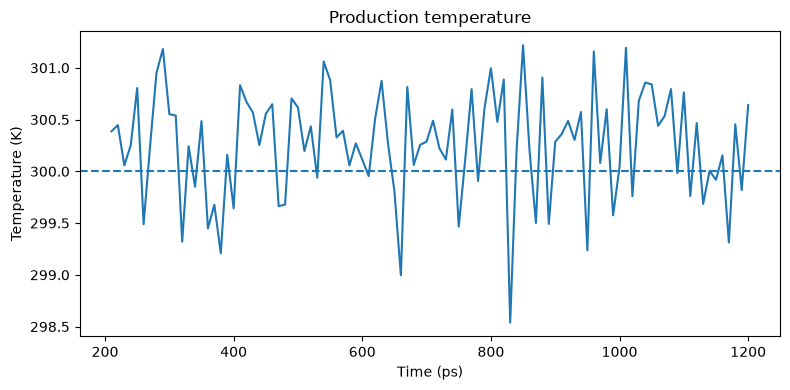

In [42]:
def find_column(
    dataframe,
    keyword,
):
    keyword = keyword.lower()

    return next(
        (
            column
            for column
            in dataframe.columns
            if keyword
            in str(column).lower()
        ),
        None,
    )

time_col = find_column(
    state_df,
    "time"
)

temperature_col = find_column(
    state_df,
    "temperature"
)

density_col = find_column(
    state_df,
    "density"
)

potential_col = find_column(
    state_df,
    "potential"
)

if (
    time_col
    and temperature_col
):
    plt.figure(
        figsize=(8, 4)
    )
    plt.plot(
        state_df[time_col],
        state_df[temperature_col],
    )
    plt.axhline(
        TEMPERATURE_K,
        linestyle="--",
    )
    plt.xlabel(
        time_col
    )
    plt.ylabel(
        temperature_col
    )
    plt.title(
        "Production temperature"
    )
    plt.tight_layout()
    plt.savefig(
        REPORT_DIR
        / "production_temperature.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()


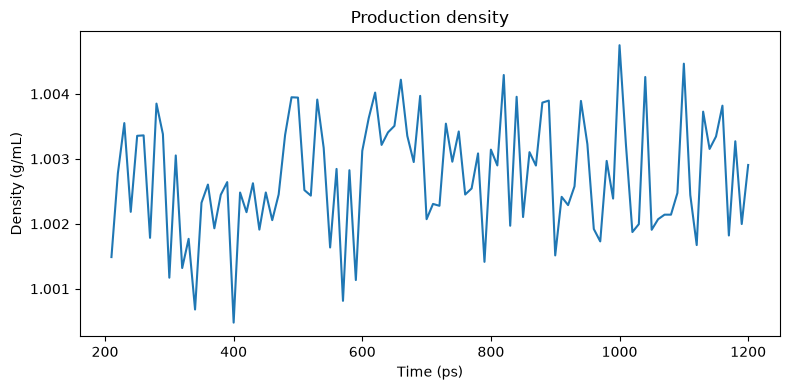

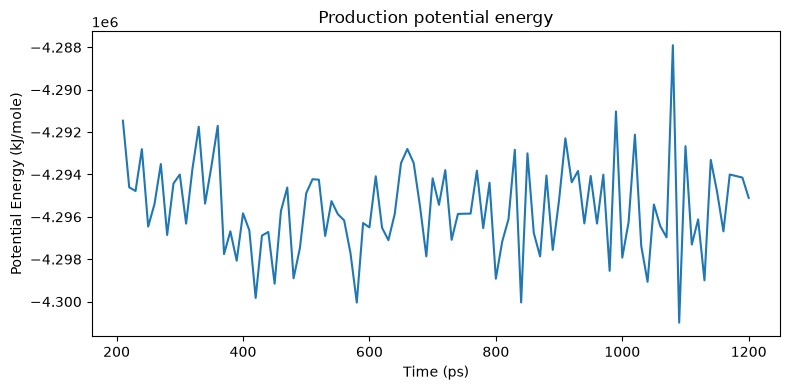

In [43]:
if (
    time_col
    and density_col
):
    plt.figure(
        figsize=(8, 4)
    )
    plt.plot(
        state_df[time_col],
        state_df[density_col],
    )
    plt.xlabel(
        time_col
    )
    plt.ylabel(
        density_col
    )
    plt.title(
        "Production density"
    )
    plt.tight_layout()
    plt.savefig(
        REPORT_DIR
        / "production_density.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()

if (
    time_col
    and potential_col
):
    plt.figure(
        figsize=(8, 4)
    )
    plt.plot(
        state_df[time_col],
        state_df[potential_col],
    )
    plt.xlabel(
        time_col
    )
    plt.ylabel(
        potential_col
    )
    plt.title(
        "Production potential energy"
    )
    plt.tight_layout()
    plt.savefig(
        REPORT_DIR
        / "production_potential_energy.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()


# 15. Load the protein trajectory with MDAnalysis

The topology and DCD contain the same B–D protein atoms in the same order.

Before calculating RMSD, RMSF or contact persistence, the trajectory is aligned to **receptor chain B**.

This removes overall translation/rotation of the receptor and makes motion of chain D interpretable relative to chain B.


In [44]:
u = mda.Universe(
    str(PROTEIN_TOPOLOGY_PDB),
    str(PROTEIN_DCD),
)

print(
    "Trajectory atoms:",
    len(u.atoms),
)
print(
    "Frames:",
    len(u.trajectory),
)
print(
    "Trajectory dt:",
    u.trajectory.dt,
    "ps",
)

chain_ids = sorted(
    {
        str(x)
        for x
        in u.atoms.chainIDs
        if str(x).strip()
    }
)

segids = sorted(
    {
        str(x)
        for x
        in u.atoms.segids
        if str(x).strip()
    }
)

print(
    "chainIDs:",
    chain_ids,
)
print(
    "segids:",
    segids,
)


Trajectory atoms: 10019
Frames: 500
Trajectory dt: 2.0000000059628116 ps
chainIDs: ['B', 'D']
segids: ['B', 'D']


## 16. Robust B/D atom selections

In [45]:
def chain_selection(
    universe,
    chain_id,
):
    chain_id_values = set(
        str(x)
        for x
        in universe.atoms.chainIDs
    )

    if chain_id in chain_id_values:
        return (
            f"chainID {chain_id}"
        )

    segid_values = set(
        str(x)
        for x
        in universe.atoms.segids
    )

    if chain_id in segid_values:
        return (
            f"segid {chain_id}"
        )

    raise ValueError(
        f"Cannot identify chain {chain_id}"
    )


SEL_B = chain_selection(
    u,
    RECEPTOR_CHAIN,
)

SEL_D = chain_selection(
    u,
    PARTNER_CHAIN,
)

print(
    "B selection:",
    SEL_B,
)
print(
    "D selection:",
    SEL_D,
)

B_all = u.select_atoms(
    SEL_B
)

D_all = u.select_atoms(
    SEL_D
)

B_CA = u.select_atoms(
    f"({SEL_B}) and name CA"
)

D_CA = u.select_atoms(
    f"({SEL_D}) and name CA"
)

B_heavy = u.select_atoms(
    f"({SEL_B}) and not name H*"
)

D_heavy = u.select_atoms(
    f"({SEL_D}) and not name H*"
)

print(
    "B atoms:",
    len(B_all),
)
print(
    "D atoms:",
    len(D_all),
)
print(
    "B CA:",
    len(B_CA),
)
print(
    "D CA:",
    len(D_CA),
)
print(
    "B heavy:",
    len(B_heavy),
)
print(
    "D heavy:",
    len(D_heavy),
)

if (
    len(B_CA) == 0
    or len(D_CA) == 0
):
    raise RuntimeError(
        "Unable to build B/D CA selections."
    )


B selection: chainID B
D selection: chainID D
B atoms: 9286
D atoms: 733
B CA: 614
D CA: 47
B heavy: 4725
D heavy: 386


## 16b. PBC and B–D complex-continuity verification

Before receptor alignment and interpretation of RMSD or interface contacts,
we verify that periodic-boundary imaging has not produced an apparent
separation of chains B and D in the protein-only trajectory.

The DCD was written with `enforcePeriodicBox=False` to avoid independently
wrapping the interacting chains. The following diagnostic compares direct
Cartesian and minimum-image B–D heavy-atom distances across the saved
trajectory.

This is a trajectory-integrity check; it does not alter or rerun the MD.

In [46]:
from MDAnalysis.lib.distances import distance_array

pbc_rows = []

for ts in u.trajectory:
    direct_min = float(
        distance_array(
            B_heavy.positions,
            D_heavy.positions,
            box=None,
        ).min()
    )

    box_available = (
        ts.dimensions is not None
        and len(ts.dimensions) >= 3
        and np.all(np.asarray(ts.dimensions[:3]) > 0)
    )

    if box_available:
        pbc_min = float(
            distance_array(
                B_heavy.positions,
                D_heavy.positions,
                box=ts.dimensions,
            ).min()
        )
    else:
        pbc_min = np.nan

    pbc_rows.append(
        {
            "frame": int(ts.frame),
            "time_ps": float(ts.time),
            "direct_min_BD_A": direct_min,
            "pbc_min_BD_A": pbc_min,
            "abs_difference_A": (
                abs(direct_min - pbc_min)
                if np.isfinite(pbc_min)
                else np.nan
            ),
        }
    )

pbc_check_df = pd.DataFrame(pbc_rows)

PBC_TOLERANCE_A = 0.5

if pbc_check_df["pbc_min_BD_A"].notna().any():
    pbc_problem_frames = pbc_check_df[
        pbc_check_df["abs_difference_A"] > PBC_TOLERANCE_A
    ].copy()

    PBC_CONTINUITY_OK = pbc_problem_frames.empty
else:
    pbc_problem_frames = pd.DataFrame()
    PBC_CONTINUITY_OK = None

display(pbc_check_df.describe())

print("Frames checked:", len(pbc_check_df))
print("PBC continuity OK:", PBC_CONTINUITY_OK)

if PBC_CONTINUITY_OK is False:
    print(
        "WARNING: direct and minimum-image B-D distances differ "
        "in one or more frames. PBC imaging must be corrected "
        "before interpreting RMSD/contact persistence."
    )
elif PBC_CONTINUITY_OK is True:
    print(
        "No relevant B-D periodic-image discontinuity detected "
        "with the selected tolerance."
    )
else:
    print(
        "Periodic box dimensions were unavailable in the "
        "protein-only trajectory; PBC equivalence could not "
        "be checked from this DCD."
    )

pbc_check_df.to_csv(
    ANALYSIS_DIR / "07b_PBC_complex_continuity_check.csv",
    index=False,
)

,frame,time_ps,direct_min_BD_A,pbc_min_BD_A,abs_difference_A
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,249.500000,501.000001,2.669888,2.669888,4.667687e-08
std,144.481833,288.963666,0.062346,0.062346,2.664714e-08
min,0.000000,2.000000,2.461366,2.461366,2.508194e-10
25%,124.750000,251.500001,2.631231,2.631231,2.338865e-08
50%,249.500000,501.000001,2.673969,2.673969,4.838399e-08
75%,374.250000,750.500002,2.713321,2.713321,7.068443e-08
max,499.000000,1000.000003,2.856639,2.856639,9.290391e-08


Frames checked: 500
PBC continuity OK: True
No relevant B-D periodic-image discontinuity detected with the selected tolerance.


In [ ]:
## 16b. PBC and B–D complex-continuity verification

Before receptor alignment and interpretation of RMSD or interface contacts,
we verify that periodic-boundary imaging has not produced an apparent
separation of chains B and D in the protein-only trajectory.

The DCD was written with `enforcePeriodicBox=False` to avoid independently
wrapping the interacting chains. The following diagnostic compares direct
Cartesian and minimum-image B–D heavy-atom distances across the saved
trajectory.

This is a trajectory-integrity check; it does not alter or rerun the MD.

In [47]:
from MDAnalysis.lib.distances import distance_array

pbc_rows = []

for ts in u.trajectory:
    direct_min = float(
        distance_array(
            B_heavy.positions,
            D_heavy.positions,
            box=None,
        ).min()
    )

    box_available = (
        ts.dimensions is not None
        and len(ts.dimensions) >= 3
        and np.all(np.asarray(ts.dimensions[:3]) > 0)
    )

    if box_available:
        pbc_min = float(
            distance_array(
                B_heavy.positions,
                D_heavy.positions,
                box=ts.dimensions,
            ).min()
        )
    else:
        pbc_min = np.nan

    pbc_rows.append(
        {
            "frame": int(ts.frame),
            "time_ps": float(ts.time),
            "direct_min_BD_A": direct_min,
            "pbc_min_BD_A": pbc_min,
            "abs_difference_A": (
                abs(direct_min - pbc_min)
                if np.isfinite(pbc_min)
                else np.nan
            ),
        }
    )

pbc_check_df = pd.DataFrame(pbc_rows)

PBC_TOLERANCE_A = 0.5

if pbc_check_df["pbc_min_BD_A"].notna().any():
    pbc_problem_frames = pbc_check_df[
        pbc_check_df["abs_difference_A"] > PBC_TOLERANCE_A
    ].copy()

    PBC_CONTINUITY_OK = pbc_problem_frames.empty
else:
    pbc_problem_frames = pd.DataFrame()
    PBC_CONTINUITY_OK = None

display(pbc_check_df.describe())

print("Frames checked:", len(pbc_check_df))
print("PBC continuity OK:", PBC_CONTINUITY_OK)

if PBC_CONTINUITY_OK is False:
    print(
        "WARNING: direct and minimum-image B-D distances differ "
        "in one or more frames. PBC imaging must be corrected "
        "before interpreting RMSD/contact persistence."
    )
elif PBC_CONTINUITY_OK is True:
    print(
        "No relevant B-D periodic-image discontinuity detected "
        "with the selected tolerance."
    )
else:
    print(
        "Periodic box dimensions were unavailable in the "
        "protein-only trajectory; PBC equivalence could not "
        "be checked from this DCD."
    )

pbc_check_df.to_csv(
    ANALYSIS_DIR / "07b_PBC_complex_continuity_check.csv",
    index=False,
)

,frame,time_ps,direct_min_BD_A,pbc_min_BD_A,abs_difference_A
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,249.500000,501.000001,2.669888,2.669888,4.667687e-08
std,144.481833,288.963666,0.062346,0.062346,2.664714e-08
min,0.000000,2.000000,2.461366,2.461366,2.508194e-10
25%,124.750000,251.500001,2.631231,2.631231,2.338865e-08
50%,249.500000,501.000001,2.673969,2.673969,4.838399e-08
75%,374.250000,750.500002,2.713321,2.713321,7.068443e-08
max,499.000000,1000.000003,2.856639,2.856639,9.290391e-08


Frames checked: 500
PBC continuity OK: True
No relevant B-D periodic-image discontinuity detected with the selected tolerance.


## 17. Receptor-aligned trajectory

In [48]:
reference = mda.Universe(
    str(PROTEIN_TOPOLOGY_PDB)
)

SEL_B_REF = chain_selection(
    reference,
    RECEPTOR_CHAIN,
)

aligner = align.AlignTraj(
    u,
    reference,
    select=f"({SEL_B}) and name CA",
    in_memory=True,
)

aligner.run()

print(
    "Trajectory aligned to chain B CA atoms."
)


Trajectory aligned to chain B CA atoms.


## 18. RMSD relative to the initial equilibrated structure

After alignment to receptor B, we calculate:

- B CA RMSD;
- D CA RMSD;
- whole B–D CA RMSD.

The D RMSD is especially useful here because it describes how much the partner chain moves relative to the receptor.


In [49]:
ref_B_CA = reference.select_atoms(
    f"({SEL_B_REF}) and name CA"
)

SEL_D_REF = chain_selection(
    reference,
    PARTNER_CHAIN,
)

ref_D_CA = reference.select_atoms(
    f"({SEL_D_REF}) and name CA"
)

ref_all_CA = reference.select_atoms(
    "name CA"
)

all_CA = u.select_atoms(
    "name CA"
)

rmsd_rows = []

for ts in u.trajectory:
    time_ps = (
        ts.frame
        * TRAJECTORY_INTERVAL_PS
    )

    B_rmsd = rms.rmsd(
        B_CA.positions,
        ref_B_CA.positions,
        center=False,
        superposition=False,
    )

    D_rmsd = rms.rmsd(
        D_CA.positions,
        ref_D_CA.positions,
        center=False,
        superposition=False,
    )

    complex_rmsd = rms.rmsd(
        all_CA.positions,
        ref_all_CA.positions,
        center=False,
        superposition=False,
    )

    rmsd_rows.append(
        {
            "frame": ts.frame,
            "time_ps": time_ps,
            "time_ns": time_ps / 1000.0,
            "B_CA_RMSD_A": B_rmsd,
            "D_CA_RMSD_A": D_rmsd,
            "complex_CA_RMSD_A": complex_rmsd,
        }
    )

rmsd_df = pd.DataFrame(
    rmsd_rows
)

rmsd_df.to_csv(
    ANALYSIS_DIR
    / "rmsd_timeseries.csv",
    index=False,
)

display(
    rmsd_df.head()
)

display(
    rmsd_df[
        [
            "B_CA_RMSD_A",
            "D_CA_RMSD_A",
            "complex_CA_RMSD_A",
        ]
    ].describe()
)


,frame,time_ps,time_ns,B_CA_RMSD_A,D_CA_RMSD_A,complex_CA_RMSD_A
0,0,0.0,0.000,0.544449,0.525921,0.543152
1,1,2.0,0.002,0.614892,0.751166,0.625563
2,2,4.0,0.004,0.660271,0.703004,0.663401
3,3,6.0,0.006,0.730015,0.748298,0.731330
4,4,8.0,0.008,0.711096,0.826118,0.719881


,B_CA_RMSD_A,D_CA_RMSD_A,complex_CA_RMSD_A
count,500.000000,500.000000,500.000000
mean,2.127050,1.317574,2.080869
std,0.417453,0.278421,0.404276
min,0.544449,0.525921,0.543152
25%,2.066973,1.138219,2.023847
50%,2.222491,1.290631,2.170808
75%,2.336994,1.512371,2.282885
max,2.747329,1.978252,2.670769


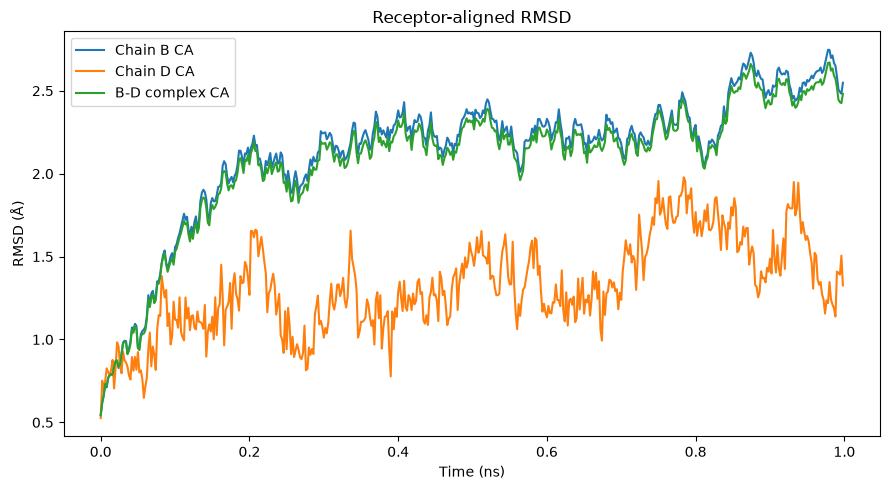

In [50]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    rmsd_df["time_ns"],
    rmsd_df["B_CA_RMSD_A"],
    label="Chain B CA",
)

plt.plot(
    rmsd_df["time_ns"],
    rmsd_df["D_CA_RMSD_A"],
    label="Chain D CA",
)

plt.plot(
    rmsd_df["time_ns"],
    rmsd_df["complex_CA_RMSD_A"],
    label="B-D complex CA",
)

plt.xlabel(
    "Time (ns)"
)
plt.ylabel(
    "RMSD (Å)"
)
plt.title(
    "Receptor-aligned RMSD"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "rmsd_receptor_aligned.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 19. RMSF

RMSF measures the mobility of each residue around its mean position.

The trajectory is already aligned to chain B, so:

- B RMSF describes receptor flexibility;
- D RMSF includes peptide/partner motion relative to the receptor.

RMSF is calculated on C-alpha atoms.


In [51]:
u.trajectory[0]

all_CA = u.select_atoms(
    "name CA"
)

rmsf_analysis = rms.RMSF(
    all_CA
)

rmsf_analysis.run()

rmsf_values = (
    rmsf_analysis.results.rmsf
)

rmsf_df = pd.DataFrame(
    {
        "chain": all_CA.chainIDs,
        "resname": all_CA.resnames,
        "resid": all_CA.resids,
        "rmsf_A": rmsf_values,
    }
)

rmsf_df.to_csv(
    ANALYSIS_DIR
    / "rmsf_ca_by_residue.csv",
    index=False,
)

display(
    rmsf_df.sort_values(
        "rmsf_A",
        ascending=False,
    ).head(20)
)


,chain,resname,resid,rmsf_A
578,B,ASN,579,4.889177
579,B,ASN,580,4.814852
248,B,THR,249,4.745304
580,B,THR,581,4.517709
250,B,TYR,251,4.516471
577,B,GLU,578,4.513050
247,B,PRO,248,4.460348
249,B,THR,250,4.441455
576,B,GLY,577,4.152226
575,B,MET,576,4.075585


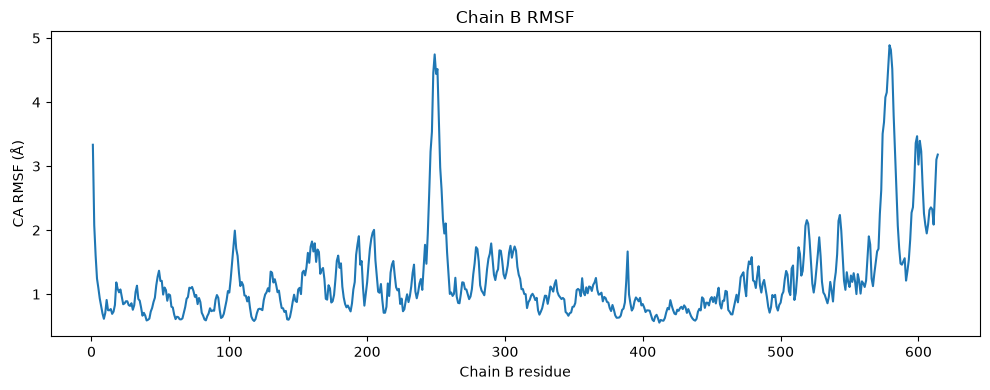

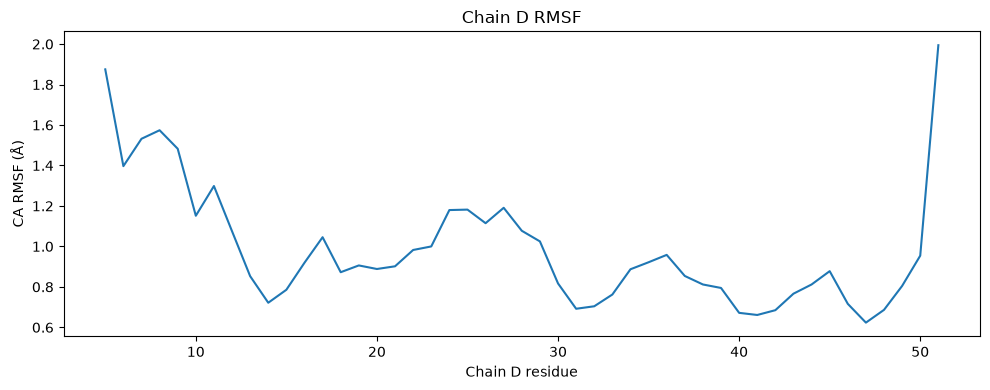

In [52]:
for chain_id in [
    RECEPTOR_CHAIN,
    PARTNER_CHAIN,
]:
    sub = rmsf_df[
        rmsf_df["chain"]
        == chain_id
    ]

    if sub.empty:
        continue

    plt.figure(
        figsize=(10, 4)
    )

    plt.plot(
        sub["resid"],
        sub["rmsf_A"],
    )

    plt.xlabel(
        f"Chain {chain_id} residue"
    )
    plt.ylabel(
        "CA RMSF (Å)"
    )
    plt.title(
        f"Chain {chain_id} RMSF"
    )
    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / f"rmsf_chain_{chain_id}.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


# 20. B–D contact persistence

A residue pair is considered in contact in a frame when **any heavy-atom pair** between the two residues is within:

```text
4.5 Å
```

For every residue-residue pair we calculate:

```text
persistence = frames_with_contact / total_frames
```

Examples:

```text
1.00  → contact present in every analysed frame
0.80  → present in 80% of frames
0.10  → transient contact
```

The default threshold for a **persistent contact** in this notebook is 50%.


In [53]:
contact_counter = Counter()
contact_distance_sum = Counter()
frame_contact_rows = []

n_frames = 0

for ts in u.trajectory:
    n_frames += 1

    pairs, distances = capped_distance(
        B_heavy.positions,
        D_heavy.positions,
        max_cutoff=CONTACT_CUTOFF_A,
        box=None,
        return_distances=True,
    )

    frame_residue_contacts = {}

    for (
        pair,
        distance,
    ) in zip(
        pairs,
        distances,
    ):
        i = int(
            pair[0]
        )
        j = int(
            pair[1]
        )

        atom_B = B_heavy[i]
        atom_D = D_heavy[j]

        key = (
            atom_B.residue.resname,
            int(atom_B.residue.resid),
            atom_D.residue.resname,
            int(atom_D.residue.resid),
        )

        if (
            key not in frame_residue_contacts
            or distance
            < frame_residue_contacts[key]
        ):
            frame_residue_contacts[key] = float(
                distance
            )

    for (
        key,
        min_distance,
    ) in frame_residue_contacts.items():
        contact_counter[key] += 1
        contact_distance_sum[key] += min_distance

    time_ps = (
        ts.frame
        * TRAJECTORY_INTERVAL_PS
    )

    frame_contact_rows.append(
        {
            "frame": ts.frame,
            "time_ps": time_ps,
            "time_ns": time_ps / 1000.0,
            "n_residue_contacts": len(
                frame_residue_contacts
            ),
        }
    )

print(
    "Analysed frames:",
    n_frames,
)

print(
    "Unique B-D residue contacts:",
    len(contact_counter),
)


Analysed frames: 500
Unique B-D residue contacts: 144


In [54]:
contact_rows = []

for (
    key,
    count,
) in contact_counter.items():
    (
        B_resname,
        B_resid,
        D_resname,
        D_resid,
    ) = key

    persistence = (
        count
        / n_frames
    )

    mean_min_distance = (
        contact_distance_sum[key]
        / count
    )

    contact_rows.append(
        {
            "B_resname": B_resname,
            "B_resid": B_resid,
            "D_resname": D_resname,
            "D_resid": D_resid,
            "frames_in_contact": count,
            "n_frames": n_frames,
            "persistence": persistence,
            "persistence_percent": (
                persistence
                * 100.0
            ),
            "mean_min_distance_A": mean_min_distance,
            "persistent_50pct": (
                persistence
                >= PERSISTENCE_THRESHOLD
            ),
        }
    )

contact_df = (
    pd.DataFrame(
        contact_rows
    )
    .sort_values(
        [
            "persistence",
            "mean_min_distance_A",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)

contact_df.to_csv(
    ANALYSIS_DIR
    / "BD_contact_persistence.csv",
    index=False,
)

display(
    contact_df.head(30)
)


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
0,ASP,355,ARG,41,500,500,1.000,100.0,2.748417,True
1,GLN,411,LYS,48,500,500,1.000,100.0,2.835348,True
2,GLN,16,CYS,31,500,500,1.000,100.0,2.933767,True
3,GLN,16,CYS,33,500,500,1.000,100.0,3.026353,True
4,ARG,29,TRP,49,500,500,1.000,100.0,3.135729,True
5,GLN,384,ARG,45,500,500,1.000,100.0,3.146737,True
6,GLN,16,ASN,32,500,500,1.000,100.0,3.288483,True
7,LEU,348,GLN,43,500,500,1.000,100.0,3.419805,True
8,THR,15,CYS,31,500,500,1.000,100.0,3.434341,True
9,THR,15,GLU,40,500,500,1.000,100.0,3.448216,True


## 21. Persistent B–D contacts

In [55]:
persistent_contacts_df = (
    contact_df[
        contact_df[
            "persistence"
        ]
        >= PERSISTENCE_THRESHOLD
    ]
    .copy()
)

persistent_contacts_df.to_csv(
    ANALYSIS_DIR
    / "BD_persistent_contacts_50pct.csv",
    index=False,
)

print(
    "Persistent contacts >= "
    f"{PERSISTENCE_THRESHOLD:.0%}:",
    len(persistent_contacts_df),
)

display(
    persistent_contacts_df.head(50)
)


Persistent contacts >= 50%: 78


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct
0,ASP,355,ARG,41,500,500,1.000,100.0,2.748417,True
1,GLN,411,LYS,48,500,500,1.000,100.0,2.835348,True
2,GLN,16,CYS,31,500,500,1.000,100.0,2.933767,True
3,GLN,16,CYS,33,500,500,1.000,100.0,3.026353,True
4,ARG,29,TRP,49,500,500,1.000,100.0,3.135729,True
5,GLN,384,ARG,45,500,500,1.000,100.0,3.146737,True
6,GLN,16,ASN,32,500,500,1.000,100.0,3.288483,True
7,LEU,348,GLN,43,500,500,1.000,100.0,3.419805,True
8,THR,15,CYS,31,500,500,1.000,100.0,3.434341,True
9,THR,15,GLU,40,500,500,1.000,100.0,3.448216,True


## 22. Contact-count stability over time

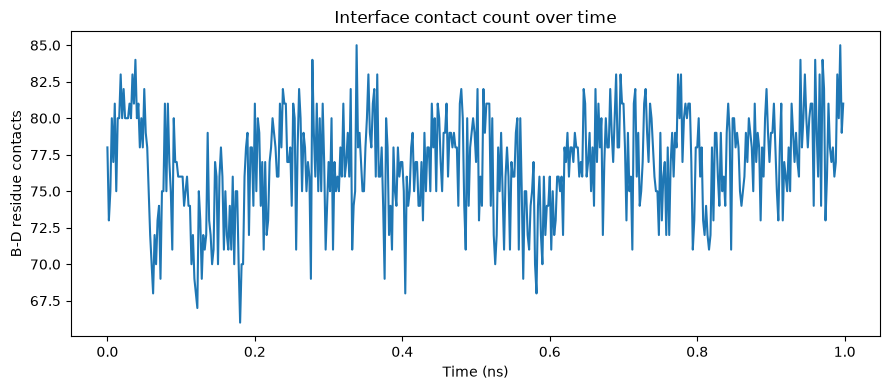

count    500.000000
mean      76.770000
std        3.518218
min       66.000000
25%       75.000000
50%       77.000000
75%       79.000000
max       85.000000
Name: n_residue_contacts, dtype: float64

In [56]:
frame_contacts_df = pd.DataFrame(
    frame_contact_rows
)

frame_contacts_df.to_csv(
    ANALYSIS_DIR
    / "BD_contact_count_timeseries.csv",
    index=False,
)

plt.figure(
    figsize=(9, 4)
)

plt.plot(
    frame_contacts_df["time_ns"],
    frame_contacts_df["n_residue_contacts"],
)

plt.xlabel(
    "Time (ns)"
)
plt.ylabel(
    "B-D residue contacts"
)
plt.title(
    "Interface contact count over time"
)
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "BD_contact_count_timeseries.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

display(
    frame_contacts_df[
        "n_residue_contacts"
    ].describe()
)


## 23. Compare initial interface contacts with their persistence

The first production frame acts as the dynamic reference.

This table answers:

> Of the contacts present at the beginning of the trajectory, which ones survive most consistently?


In [57]:
u.trajectory[0]

pairs_0, distances_0 = capped_distance(
    B_heavy.positions,
    D_heavy.positions,
    max_cutoff=CONTACT_CUTOFF_A,
    box=None,
    return_distances=True,
)

initial_contact_keys = set()

for pair in pairs_0:
    atom_B = B_heavy[
        int(pair[0])
    ]

    atom_D = D_heavy[
        int(pair[1])
    ]

    initial_contact_keys.add(
        (
            atom_B.residue.resname,
            int(atom_B.residue.resid),
            atom_D.residue.resname,
            int(atom_D.residue.resid),
        )
    )

contact_df["present_initial_frame"] = [
    (
        row.B_resname,
        int(row.B_resid),
        row.D_resname,
        int(row.D_resid),
    )
    in initial_contact_keys
    for row in contact_df.itertuples()
]

initial_persistence_df = (
    contact_df[
        contact_df[
            "present_initial_frame"
        ]
    ]
    .sort_values(
        "persistence",
        ascending=False,
    )
    .copy()
)

initial_persistence_df.to_csv(
    ANALYSIS_DIR
    / "initial_contacts_with_persistence.csv",
    index=False,
)

print(
    "Initial B-D residue contacts:",
    len(initial_contact_keys),
)

display(
    initial_persistence_df.head(50)
)


Initial B-D residue contacts: 78


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct,present_initial_frame
0,ASP,355,ARG,41,500,500,1.000,100.0,2.748417,True,True
10,PHE,357,TYR,13,500,500,1.000,100.0,3.450360,True,True
17,LEU,69,ILE,23,500,500,1.000,100.0,3.788779,True,True
16,LEU,325,LEU,15,500,500,1.000,100.0,3.747981,True,True
15,LEU,325,ARG,41,500,500,1.000,100.0,3.589545,True,True
14,ILE,438,LEU,47,500,500,1.000,100.0,3.589526,True,True
13,PHE,412,LEU,47,500,500,1.000,100.0,3.508575,True,True
12,THR,15,CYS,33,500,500,1.000,100.0,3.505597,True,True
11,PHE,357,ARG,41,500,500,1.000,100.0,3.475767,True,True
1,GLN,411,LYS,48,500,500,1.000,100.0,2.835348,True,True


## 24. Contacts gained during MD

In [58]:
new_contacts_df = (
    contact_df[
        ~contact_df[
            "present_initial_frame"
        ]
    ]
    .sort_values(
        "persistence",
        ascending=False,
    )
    .copy()
)

new_contacts_df.to_csv(
    ANALYSIS_DIR
    / "contacts_gained_during_MD.csv",
    index=False,
)

print(
    "Contacts not present in initial frame:",
    len(new_contacts_df),
)

display(
    new_contacts_df.head(30)
)


Contacts not present in initial frame: 66


,B_resname,B_resid,D_resname,D_resid,frames_in_contact,n_frames,persistence,persistence_percent,mean_min_distance_A,persistent_50pct,present_initial_frame
24,LEU,382,TYR,44,496,500,0.992,99.2,3.645738,True,False
38,HIS,346,TYR,44,482,500,0.964,96.4,3.132900,True,False
45,HIS,409,LYS,48,478,500,0.956,95.6,3.863160,True,False
50,LEU,14,ILE,23,457,500,0.914,91.4,3.891967,True,False
53,TYR,45,MET,21,445,500,0.890,89.0,3.717410,True,False
59,GLN,384,TYR,37,411,500,0.822,82.2,3.916082,True,False
60,ARG,29,TRP,50,402,500,0.804,80.4,3.524422,True,False
62,GLN,408,ARG,45,392,500,0.784,78.4,3.474068,True,False
74,PHE,380,TYR,44,307,500,0.614,61.4,3.994573,True,False
76,LEU,14,MET,21,266,500,0.532,53.2,4.020215,True,False


## 25. Residue-level interface persistence

In [59]:
B_residue_stats = (
    contact_df
    .groupby(
        [
            "B_resid",
            "B_resname",
        ]
    )
    .agg(
        max_contact_persistence=(
            "persistence",
            "max",
        ),
        mean_contact_persistence=(
            "persistence",
            "mean",
        ),
        n_partner_residues=(
            "D_resid",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        "max_contact_persistence",
        ascending=False,
    )
)

D_residue_stats = (
    contact_df
    .groupby(
        [
            "D_resid",
            "D_resname",
        ]
    )
    .agg(
        max_contact_persistence=(
            "persistence",
            "max",
        ),
        mean_contact_persistence=(
            "persistence",
            "mean",
        ),
        n_partner_residues=(
            "B_resid",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        "max_contact_persistence",
        ascending=False,
    )
)

B_residue_stats.to_csv(
    ANALYSIS_DIR
    / "chain_B_residue_contact_persistence.csv",
    index=False,
)

D_residue_stats.to_csv(
    ANALYSIS_DIR
    / "chain_D_residue_contact_persistence.csv",
    index=False,
)

print("Top chain-B dynamic interface residues:")
display(B_residue_stats.head(20))

print("Top chain-D dynamic interface residues:")
display(D_residue_stats.head(20))


Top chain-B dynamic interface residues:


,B_resid,B_resname,max_contact_persistence,mean_contact_persistence,n_partner_residues
27,325,LEU,1.000,0.785000,4
12,29,ARG,1.000,0.472000,4
40,384,GLN,1.000,0.954400,5
35,357,PHE,1.000,0.919333,6
33,355,ASP,1.000,0.680667,3
29,348,LEU,1.000,0.652500,4
44,412,PHE,1.000,0.960000,2
16,69,LEU,1.000,0.918667,3
48,438,ILE,1.000,1.000000,1
43,411,GLN,1.000,1.000000,1


Top chain-D dynamic interface residues:


,D_resid,D_resname,max_contact_persistence,mean_contact_persistence,n_partner_residues
18,32,ASN,1.000,0.457000,4
10,23,ILE,1.000,0.720000,4
28,43,GLN,1.000,0.754500,4
26,41,ARG,1.000,0.644333,6
25,40,GLU,1.000,0.931500,4
32,47,LEU,1.000,0.650222,9
19,33,CYS,1.000,0.767500,4
17,31,CYS,1.000,0.716000,3
30,45,ARG,1.000,0.465429,7
34,49,TRP,1.000,0.576400,5


## 26. Contact-persistence heat map

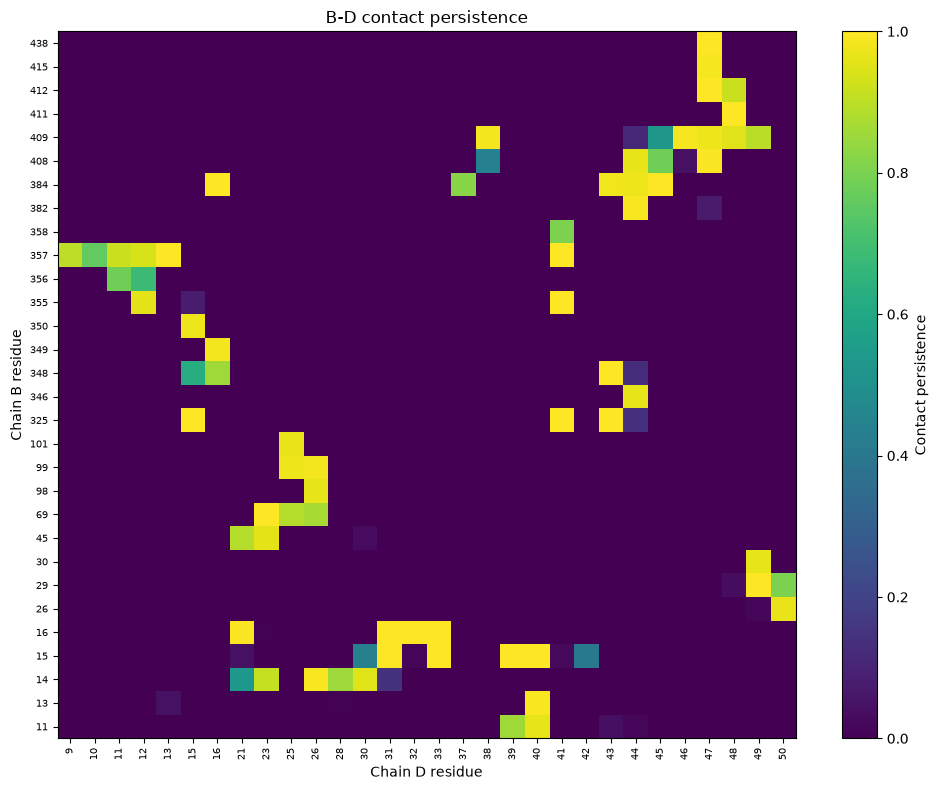

In [60]:
if not contact_df.empty:
    top_B_residues = (
        B_residue_stats
        .head(30)["B_resid"]
        .tolist()
    )

    top_D_residues = (
        D_residue_stats
        .head(30)["D_resid"]
        .tolist()
    )

    heat_df = (
        contact_df[
            contact_df[
                "B_resid"
            ].isin(
                top_B_residues
            )
            & contact_df[
                "D_resid"
            ].isin(
                top_D_residues
            )
        ]
        .pivot_table(
            index="B_resid",
            columns="D_resid",
            values="persistence",
            fill_value=0.0,
            aggfunc="max",
        )
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.imshow(
        heat_df.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=1,
    )

    plt.colorbar(
        label="Contact persistence"
    )

    plt.xticks(
        range(
            len(
                heat_df.columns
            )
        ),
        heat_df.columns,
        rotation=90,
        fontsize=7,
    )

    plt.yticks(
        range(
            len(
                heat_df.index
            )
        ),
        heat_df.index,
        fontsize=7,
    )

    plt.xlabel(
        "Chain D residue"
    )
    plt.ylabel(
        "Chain B residue"
    )
    plt.title(
        "B-D contact persistence"
    )
    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / "BD_contact_persistence_heatmap.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


## 27. Optional hotspot annotation

Pipeline 1/2 contains energetic hotspot information from FoldX.

This notebook intentionally does **not guess hotspot residue IDs**.

If a hotspot table is later connected to Pipeline 3, the dynamic persistence table can be merged with those experimentally/computationally defined hotspot labels.

For now the notebook reports **dynamic interface residues** independently from the FoldX hotspot definition.


## 28. Summary metrics and QC

In [61]:
temperature_mean = (
    float(
        state_df[
            temperature_col
        ].mean()
    )
    if temperature_col
    else np.nan
)

temperature_std = (
    float(
        state_df[
            temperature_col
        ].std()
    )
    if temperature_col
    else np.nan
)

density_mean = (
    float(
        state_df[
            density_col
        ].mean()
    )
    if density_col
    else np.nan
)

mean_contact_count = float(
    frame_contacts_df[
        "n_residue_contacts"
    ].mean()
)

initial_count = len(
    initial_contact_keys
)

persistent_initial_count = int(
    (
        initial_persistence_df[
            "persistence"
        ]
        >= PERSISTENCE_THRESHOLD
    ).sum()
)

initial_contact_retention_fraction = (
    persistent_initial_count
    / initial_count
    if initial_count > 0
    else np.nan
)

qc_rows = [
    {
        "check": "07a_qc_passed",
        "value": bool(
            config_07a.get(
                "all_qc_passed",
                False,
            )
        ),
    },
    {
        "check": "trajectory_exists",
        "value": PROTEIN_DCD.exists(),
    },
    {
        "check": "trajectory_has_frames",
        "value": len(u.trajectory) > 0,
    },
    {
        "check": "finite_mean_temperature",
        "value": np.isfinite(
            temperature_mean
        ),
    },
    {
        "check": "finite_mean_density",
        "value": np.isfinite(
            density_mean
        ),
    },
    {
        "check": "BD_contacts_detected",
        "value": len(contact_df) > 0,
    },
    {
        "check": "rmsd_generated",
        "value": len(rmsd_df) > 0,
    },
    {
        "check": "rmsf_generated",
        "value": len(rmsf_df) > 0,
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

display(qc_df)

ALL_QC_PASSED = bool(
    qc_df["value"].all()
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

summary_metrics = {
    "run_label": RUN_LABEL,
    "fast_test_mode": FAST_TEST_MODE,
    "production_ns": PRODUCTION_NS,
    "n_frames": int(n_frames),
    "temperature_mean_K": temperature_mean,
    "temperature_std_K": temperature_std,
    "density_mean": density_mean,
    "mean_BD_residue_contacts_per_frame": mean_contact_count,
    "unique_BD_contacts": int(len(contact_df)),
    "persistent_contacts_threshold": PERSISTENCE_THRESHOLD,
    "n_persistent_BD_contacts": int(len(persistent_contacts_df)),
    "n_initial_contacts": int(initial_count),
    "n_initial_contacts_persistent": int(persistent_initial_count),
    "initial_contact_retention_fraction": float(initial_contact_retention_fraction),
    "B_CA_RMSD_mean_A": float(rmsd_df["B_CA_RMSD_A"].mean()),
    "D_CA_RMSD_mean_A": float(rmsd_df["D_CA_RMSD_A"].mean()),
    "complex_CA_RMSD_mean_A": float(rmsd_df["complex_CA_RMSD_A"].mean()),
    "production_elapsed_min": float(production_elapsed_min),
    "simulated_ns_per_day": float(simulated_ns_per_day),
    "openmm_platform": selected_platform_name,
    "all_qc_passed": ALL_QC_PASSED,
}

summary_df = pd.DataFrame(
    [
        summary_metrics
    ]
)

summary_df.to_csv(
    ANALYSIS_DIR
    / "07b_summary_metrics.csv",
    index=False,
)

display(
    summary_df.T
)


,check,value
0,07a_qc_passed,True
1,trajectory_exists,True
2,trajectory_has_frames,True
3,finite_mean_temperature,True
4,finite_mean_density,True
5,BD_contacts_detected,True
6,rmsd_generated,True
7,rmsf_generated,True


ALL QC PASSED: True


,0
run_label,production_1ns
fast_test_mode,False
production_ns,1.0
n_frames,500
temperature_mean_K,300.261451
temperature_std_K,0.523799
density_mean,1.002728
mean_BD_residue_contacts_per_frame,76.77
unique_BD_contacts,144
persistent_contacts_threshold,0.5


## 29. Save configuration and automatic report

In [62]:
config = {
    "input_07a": str(INPUT_07A),
    "receptor_chain": RECEPTOR_CHAIN,
    "partner_chain": PARTNER_CHAIN,
    "contact_cutoff_A": CONTACT_CUTOFF_A,
    "persistence_threshold": PERSISTENCE_THRESHOLD,
    "temperature_K": TEMPERATURE_K,
    "friction_per_ps": FRICTION_PER_PS,
    "timestep_ps": TIMESTEP_PS,
    "fast_test_mode": FAST_TEST_MODE,
    "production_ns": PRODUCTION_NS,
    "trajectory_interval_ps": TRAJECTORY_INTERVAL_PS,
    "state_interval_ps": STATE_INTERVAL_PS,
    "checkpoint_interval_ps": CHECKPOINT_INTERVAL_PS,
    "platform": selected_platform_name,
    "random_seed": RANDOM_SEED,
}

CONFIG_JSON.write_text(
    json.dumps(
        config,
        indent=2,
    ),
    encoding="utf-8",
)

qc_df.to_csv(
    ANALYSIS_DIR
    / "07b_qc.csv",
    index=False,
)

top_contacts_text = "\n".join(
    [
        (
            f"- B:{row.B_resname}{int(row.B_resid)} "
            f"- D:{row.D_resname}{int(row.D_resid)}: "
            f"{row.persistence_percent:.1f}%"
        )
        for row
        in contact_df.head(10).itertuples()
    ]
)

report = f"""# 07b - EGFR B-D Production MD and Contact Persistence

## Run
- Mode: {RUN_LABEL}
- Production length: {PRODUCTION_NS:.3f} ns
- OpenMM platform: {selected_platform_name}
- Protein trajectory frames: {n_frames}
- Contact cutoff: {CONTACT_CUTOFF_A:.1f} A
- Persistent-contact threshold: {PERSISTENCE_THRESHOLD:.0%}

## Thermodynamics
- Mean temperature: {temperature_mean:.3f} K
- Temperature SD: {temperature_std:.3f} K
- Mean density: {density_mean:.6f}

## RMSD
- Mean chain-B CA RMSD: {rmsd_df["B_CA_RMSD_A"].mean():.3f} A
- Mean chain-D CA RMSD: {rmsd_df["D_CA_RMSD_A"].mean():.3f} A
- Mean complex CA RMSD: {rmsd_df["complex_CA_RMSD_A"].mean():.3f} A

## Interface contacts
- Unique B-D residue contacts observed: {len(contact_df)}
- Persistent contacts >= {PERSISTENCE_THRESHOLD:.0%}: {len(persistent_contacts_df)}
- Contacts in initial frame: {initial_count}
- Initial contacts persistent >= threshold: {persistent_initial_count}
- Initial-contact retention fraction: {initial_contact_retention_fraction:.3f}
- Mean B-D residue contacts/frame: {mean_contact_count:.3f}

## Top persistent contacts
{top_contacts_text}

## Runtime
- Elapsed: {production_elapsed_min:.2f} min
- Approximate speed: {simulated_ns_per_day:.2f} ns/day

## QC
- ALL QC PASSED: {ALL_QC_PASSED}

## Interpretation
This analysis measures dynamic structural persistence of the EGFR B-D interface.
It does not provide experimental binding affinity.

A longer trajectory should be used before making strong claims about equilibrium
or long-timescale interface stability.
"""

REPORT_MD = (
    REPORT_DIR
    / "07b_MD_contact_persistence_report.md"
)

REPORT_MD.write_text(
    report,
    encoding="utf-8",
)

print(report)

print(
    "Report:",
    REPORT_MD.resolve(),
)


# 07b - EGFR B-D Production MD and Contact Persistence

## Run
- Mode: production_1ns
- Production length: 1.000 ns
- OpenMM platform: OpenCL
- Protein trajectory frames: 500
- Contact cutoff: 4.5 A
- Persistent-contact threshold: 50%

## Thermodynamics
- Mean temperature: 300.261 K
- Temperature SD: 0.524 K
- Mean density: 1.002728

## RMSD
- Mean chain-B CA RMSD: 2.127 A
- Mean chain-D CA RMSD: 1.318 A
- Mean complex CA RMSD: 2.081 A

## Interface contacts
- Unique B-D residue contacts observed: 144
- Persistent contacts >= 50%: 78
- Contacts in initial frame: 78
- Initial contacts persistent >= threshold: 67
- Initial-contact retention fraction: 0.859
- Mean B-D residue contacts/frame: 76.770

## Top persistent contacts
- B:ASP355 - D:ARG41: 100.0%
- B:GLN411 - D:LYS48: 100.0%
- B:GLN16 - D:CYS31: 100.0%
- B:GLN16 - D:CYS33: 100.0%
- B:ARG29 - D:TRP49: 100.0%
- B:GLN384 - D:ARG45: 100.0%
- B:GLN16 - D:ASN32: 100.0%
- B:LEU348 - D:GLN43: 100.0%
- B:THR15 - D:CYS31: 100.0%
- B:THR15 -

# 30. Decision for the next run

## If this is the 100 ps test

If:

```text
FAST_TEST_MODE = True
ALL QC PASSED = True
```

then the workflow is technically validated.

Next:

```python
FAST_TEST_MODE = False
```

and rerun the notebook to obtain the **1 ns production prototype**.

---

## If this is the 1 ns run

The next scientific decision should be based on:

- receptor-aligned D RMSD;
- whether RMSD begins to plateau;
- residue RMSF;
- contact-count stability;
- persistence of the original B–D interface;
- identity of the most persistent contacts.

If the 1 ns trajectory is stable and informative, the same protocol can then be extended to **5–10 ns** before considering substantially longer runs.

The original PEARL specification mentions 50–100 ns, but that should only be attempted after the shorter workflow has been verified and the computational cost is justified.

---

## Main outputs

```text
analysis/
├── rmsd_timeseries.csv
├── rmsf_ca_by_residue.csv
├── BD_contact_persistence.csv
├── BD_persistent_contacts_50pct.csv
├── BD_contact_count_timeseries.csv
├── initial_contacts_with_persistence.csv
├── contacts_gained_during_MD.csv
├── chain_B_residue_contact_persistence.csv
├── chain_D_residue_contact_persistence.csv
└── 07b_summary_metrics.csv

reports/
├── production_temperature.png
├── production_density.png
├── production_potential_energy.png
├── rmsd_receptor_aligned.png
├── rmsf_chain_B.png
├── rmsf_chain_D.png
├── BD_contact_count_timeseries.png
├── BD_contact_persistence_heatmap.png
└── 07b_MD_contact_persistence_report.md
```
